In [25]:
import pandas as pd
from matplotlib import pyplot as plt
import re
import numpy as np
import os
from os.path import join as pjoin

In [23]:
root = '../../'
dataset_path = 'data/raw/mcmurray_facies_dataframe.h5'
dataset_path = pjoin(root, dataset_path)

In [5]:
df = pd.read_hdf(dataset_path)

In [6]:
df['UWI'].unique().shape

(1230,)

In [7]:
df.columns

Index(['CALI', 'COND', 'DELT', 'DEPT', 'DPHI', 'DT', 'GR', 'ILD', 'ILM',
       'NPHI', 'PHID', 'RHOB', 'SFL', 'SFLU', 'SN', 'SP', 'UWI', 'SitID',
       'lat', 'lng', 'Depth', 'LithID', 'W_Tar', 'SW', 'VSH', 'PHI', 'RW',
       'lithName'],
      dtype='object')

In [10]:
df['RW'] = df['RW'].str.strip().apply(lambda x: float(x) if x else np.nan)

Text(0, 0.5, 'Percentage of missing values')

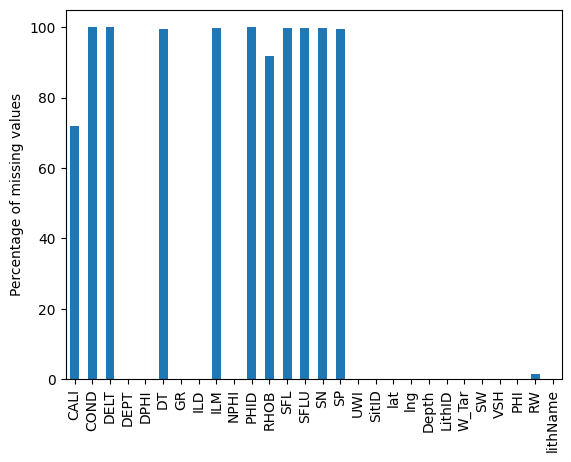

In [11]:
((df.isna().sum()/df.shape[0])*100).plot(kind='bar')
plt.ylabel('Percentage of missing values')

In [12]:
dfFiltered = df.drop(['CALI', 'DELT', 'DT', 'ILM', 'PHID', 'RHOB', 'SFL', 'SFLU', 'SN', 'SP', 'COND'], axis=1)

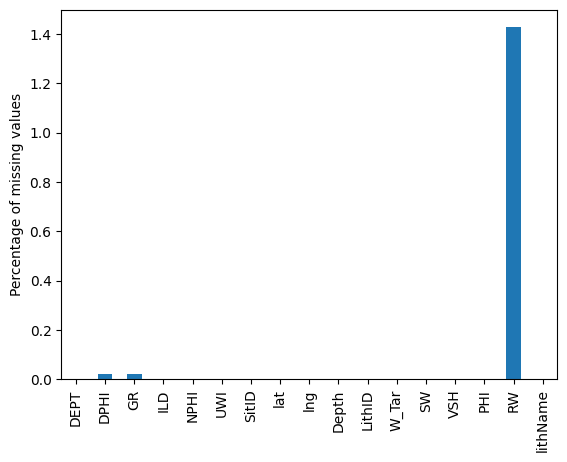

In [13]:
((dfFiltered.isna().sum()/dfFiltered.shape[0])*100).plot(kind='bar')
plt.ylabel('Percentage of missing values')
plt.show()

In [17]:
dfFiltered = dfFiltered.drop(['Depth', 'lithName', 'SitID'], axis=1)

In [18]:
dfFiltered = dfFiltered.dropna()

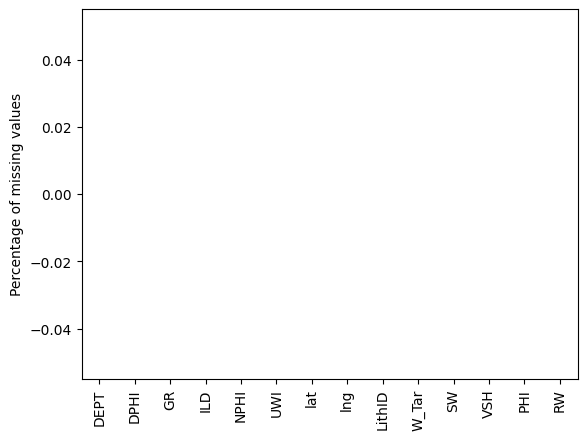

In [19]:
((dfFiltered.isna().sum()/dfFiltered.shape[0])*100).plot(kind='bar')
plt.ylabel('Percentage of missing values')
plt.show()

In [20]:
labels = dfFiltered.LithID
dfFiltered = dfFiltered.drop(['LithID'], axis=1)

In [21]:
labels = labels.astype('int')

In [26]:
folder_name = 'data/filtered'
os.makedirs(pjoin(root, folder_name), exist_ok=True)
dfFiltered.to_hdf(pjoin(root, folder_name, 'X.h5'), key='X', mode='w')
labels.to_hdf(pjoin(root, folder_name, 'Y.h5'), key='X', mode='w')